# Notebook 06 — LSTM

In [2]:
# ══════════════════════════════════════════════════════════════════
# NOTEBOOK 06 — LSTM/GRU Multivariante (WTI + BCE)
# ══════════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install tensorflow
!pip install yfinance
import yfinance as yf

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error
)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

H        = 12
LOOKBACK = 24
N_FEAT   = 3   # ventas + WTI + BCE
UNIDADES = 64
DROPOUT  = 0.2
LR       = 1e-3
EPOCHS   = 200
BATCH    = 16

tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow {tf.__version__}')


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


TensorFlow 2.21.0



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ── 1. Ventas mensuales ───────────────────────────────────────────
df = pd.read_excel('../data/processed/datos.xlsx')
df['FECHA'] = pd.to_datetime(df['FECHA'])

df_ventas = df[df['TIPO_OPERACION'] == 'VENTA'].copy()
df_ventas['PERIODO'] = df_ventas['FECHA'].dt.to_period('M')

ventas_mensual = (
    df_ventas
    .groupby(['PERIODO', 'FAMILIA'])['PESO_BRUTO']
    .sum()
    .unstack('FAMILIA')
    .sort_index()
    .fillna(0)
)

FAMILIAS  = ventas_mensual.columns.tolist()
fecha_ini = ventas_mensual.index[0].to_timestamp()
fecha_fin = ventas_mensual.index[-1].to_timestamp()

print(f'Periodo: {ventas_mensual.index[0]} -> {ventas_mensual.index[-1]}')
print(f'Familias: {FAMILIAS}')

Periodo: 2010-12 -> 2026-02
Familias: [106, 124, 233]


In [4]:
# ── 2. Regresores exógenos ────────────────────────────────────────

# 2.1 Futuros WTI
print('\nDescargando WTI (CL=F)...')
try:
    # Añadimos group_by='column' para evitar MultiIndex problemáticos en las columnas
    wti_raw = yf.download('CL=F',
                           start=str(fecha_ini.date()),
                           end=str(fecha_fin.date()),
                           interval='1mo', progress=False, auto_adjust=True, group_by='column')
    
    # Extraemos la columna 'Close' limpiando cualquier nivel extra de índice
    wti_values = wti_raw['Close'].values.flatten()
    
    # Creamos el DataFrame limpio directamente
    wti_m = pd.DataFrame({'WTI_USD': wti_values}, index=pd.to_datetime(wti_raw.index).to_period('M'))
    print(f'   WTI OK: {len(wti_m)} meses')
except Exception as e:
    print(f'   Fallo descarga WTI ({e}) — usando serie de respaldo')
    idx_bk     = pd.period_range(ventas_mensual.index[0],
                                 ventas_mensual.index[-1], freq='M')
    t_bk       = np.arange(len(idx_bk))
    wti_values = np.clip(
        60 + 40*np.sin(2*np.pi*t_bk/96) + 20*np.sin(2*np.pi*t_bk/24)
        + np.random.normal(0, 3, len(idx_bk)), 20, 130
    )
    wti_m = pd.DataFrame({'WTI_USD': wti_values}, index=idx_bk)

# 2.2 Tipo de depósito BCE (serie oficial hardcodeada)
# Fuente: https://www.ecb.europa.eu/stats/policy_and_exchange_rates/key_ecb_interest_rates
bce_cambios = {
    '2009-01': 2.00, '2009-03': 1.00, '2009-04': 0.75,
    '2009-05': 0.50, '2009-06': 0.25,
    '2011-04': 0.50, '2011-07': 0.75,
    '2012-07': 0.00,
    '2014-06': -0.10, '2015-12': -0.30, '2016-03': -0.40,
    '2019-09': -0.50,
    '2022-07':  0.00, '2022-09':  0.75,
    '2022-11':  1.50, '2022-12':  2.00,
    '2023-02':  2.50, '2023-03':  3.00,
    '2023-05':  3.25, '2023-06':  3.50,
    '2023-09':  4.00,
    '2024-06':  3.75, '2024-09':  3.50,
    '2024-10':  3.25, '2024-12':  3.00,
    '2025-01':  2.75, '2025-03':  2.50,
    '2025-04':  2.25,
}

idx_bce    = pd.period_range(ventas_mensual.index[0],
                              ventas_mensual.index[-1], freq='M')
tipo_actual = 2.00
valores_bce = []
for p in idx_bce:
    if str(p) in bce_cambios:
        tipo_actual = bce_cambios[str(p)]
    valores_bce.append(tipo_actual)
bce_m = pd.DataFrame({'BCE_%': valores_bce}, index=idx_bce)
print(f'BCE OK: {len(bce_m)} meses')

# Alinear con ventas
df_exog = pd.DataFrame(index=ventas_mensual.index)
df_exog = df_exog.join(wti_m['WTI_USD'], how='left')
df_exog = df_exog.join(bce_m['BCE_%'],   how='left')
df_exog = df_exog.ffill().bfill()
print(f'NaN en exógenos: {df_exog.isna().sum().sum()}')


Descargando WTI (CL=F)...
   WTI OK: 156 meses
BCE OK: 183 meses
NaN en exógenos: 0


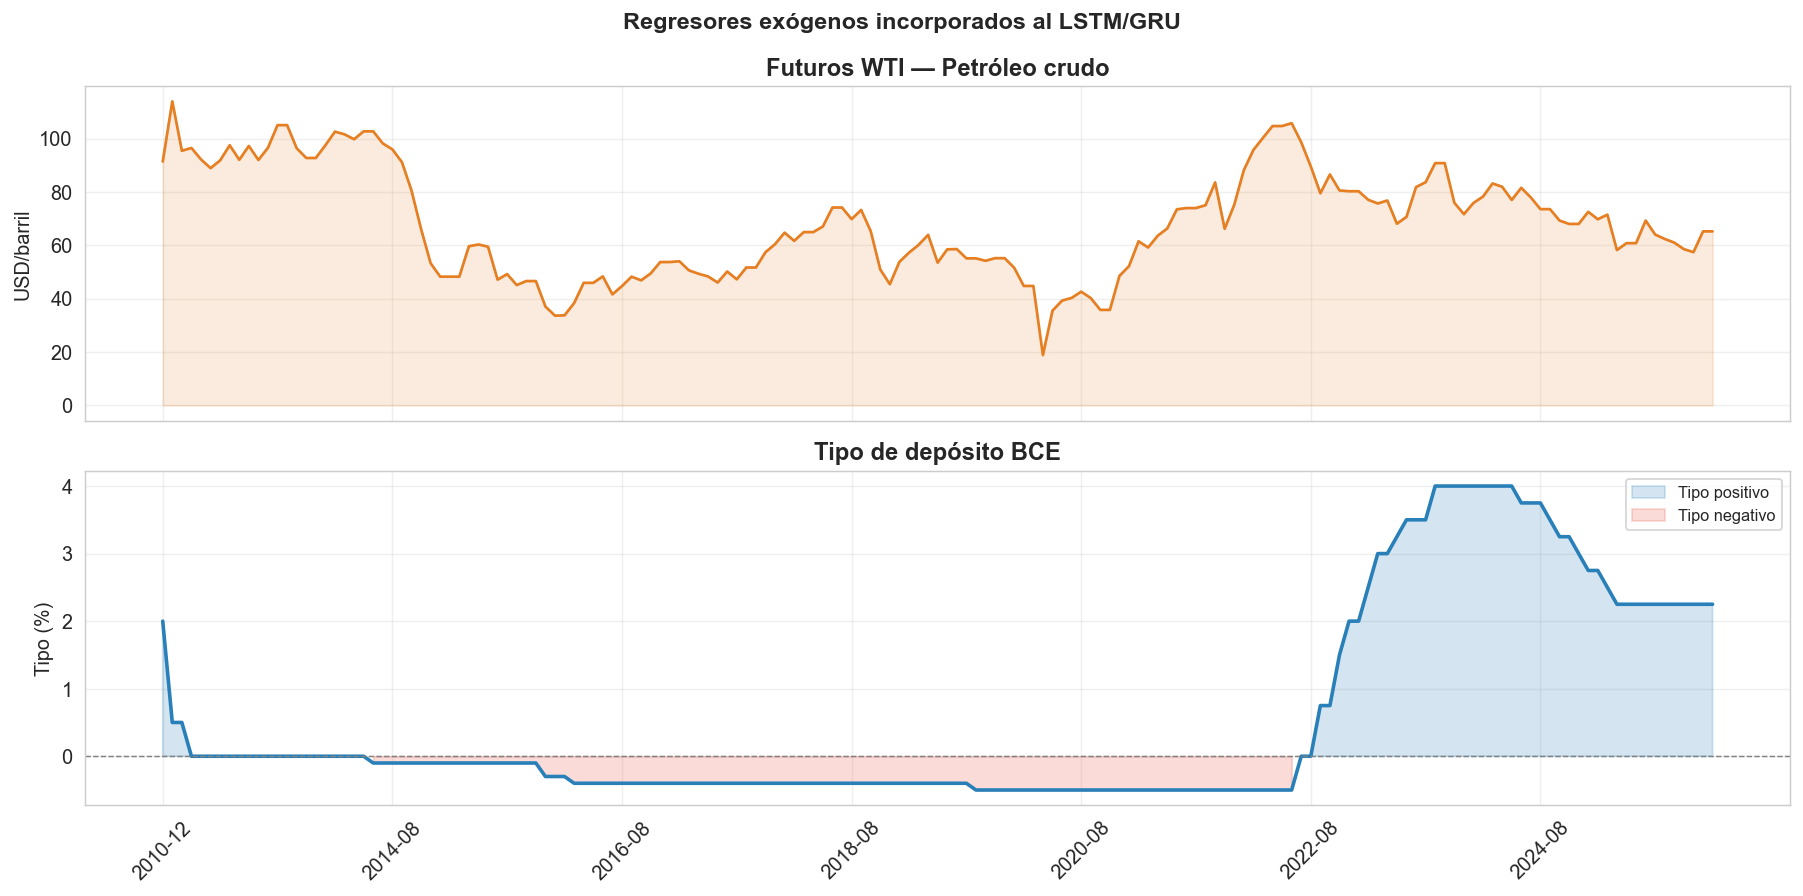

In [5]:
# ── 3. Visualización de regresores ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
idx_str = df_exog.index.astype(str)
ticks   = range(0, len(idx_str), 24)

axes[0].plot(idx_str, df_exog['WTI_USD'], color='#e67e22', lw=1.5)
axes[0].fill_between(idx_str, df_exog['WTI_USD'], alpha=0.15, color='#e67e22')
axes[0].set_ylabel('USD/barril')
axes[0].set_title('Futuros WTI — Petróleo crudo', fontweight='bold')
axes[0].set_xticks([idx_str[i] for i in ticks])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

axes[1].plot(idx_str, df_exog['BCE_%'], color='#2980b9', lw=2.0)
axes[1].axhline(0, color='grey', lw=0.8, ls='--')
axes[1].fill_between(idx_str, df_exog['BCE_%'], 0,
                      where=df_exog['BCE_%'] >= 0,
                      alpha=0.2, color='#2980b9', label='Tipo positivo')
axes[1].fill_between(idx_str, df_exog['BCE_%'], 0,
                      where=df_exog['BCE_%'] < 0,
                      alpha=0.2, color='#e74c3c', label='Tipo negativo')
axes[1].set_ylabel('Tipo (%)')
axes[1].set_title('Tipo de depósito BCE', fontweight='bold')
axes[1].set_xticks([idx_str[i] for i in ticks])
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Regresores exógenos incorporados al LSTM/GRU',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figuras/05_regresores_exogenos.pdf', bbox_inches='tight')
plt.show()

In [6]:
# ── 4. Correlación exógenos-ventas ────────────────────────────────
print('\nCorrelacion Pearson (ventas ~ regresores) por familia:')
for familia in FAMILIAS:
    ventas = ventas_mensual[familia]
    for nombre, col in [('WTI', 'WTI_USD'), ('BCE', 'BCE_%')]:
        for lag in [0, 1, 3, 6]:
            r = np.corrcoef(
                ventas.values[lag:],
                df_exog[col].shift(lag).dropna().values
            )[0, 1]
            print(f'  [{familia}] {nombre} lag={lag}: r={r:+.3f}')


Correlacion Pearson (ventas ~ regresores) por familia:
  [106] WTI lag=0: r=+0.028
  [106] WTI lag=1: r=+0.027
  [106] WTI lag=3: r=-0.021
  [106] WTI lag=6: r=-0.007
  [106] BCE lag=0: r=+0.269
  [106] BCE lag=1: r=+0.256
  [106] BCE lag=3: r=+0.257
  [106] BCE lag=6: r=+0.234
  [124] WTI lag=0: r=+0.129
  [124] WTI lag=1: r=+0.098
  [124] WTI lag=3: r=+0.113
  [124] WTI lag=6: r=+0.159
  [124] BCE lag=0: r=+0.589
  [124] BCE lag=1: r=+0.570
  [124] BCE lag=3: r=+0.541
  [124] BCE lag=6: r=+0.489
  [233] WTI lag=0: r=-0.170
  [233] WTI lag=1: r=-0.140
  [233] WTI lag=3: r=-0.077
  [233] WTI lag=6: r=-0.009
  [233] BCE lag=0: r=-0.329
  [233] BCE lag=1: r=-0.333
  [233] BCE lag=3: r=-0.323
  [233] BCE lag=6: r=-0.290


In [7]:
# ── 5. Secuencias multivariantes ──────────────────────────────────
def preparar_secuencias_multi(series_sc, lookback, H):
    """
    Entrada:  series_sc shape (n, n_features) normalizado
    X[i]:     series_sc[i-lookback:i, :]    shape (lookback, n_features)
    y[i]:     series_sc[i:i+H, 0]           shape (H,) — solo ventas
    """
    X, y = [], []
    for i in range(lookback, len(series_sc) - H + 1):
        X.append(series_sc[i - lookback : i, :])
        y.append(series_sc[i : i + H, 0])
    return np.array(X), np.array(y)


datos_dl = {}

for familia in FAMILIAS:
    ventas = ventas_mensual[familia].values.astype(float)
    wti    = df_exog['WTI_USD'].values.astype(float)
    bce    = df_exog['BCE_%'].values.astype(float)

    sc_v = MinMaxScaler((0, 1))
    sc_w = MinMaxScaler((0, 1))
    sc_b = MinMaxScaler((0, 1))

    series_sc = np.stack([
        sc_v.fit_transform(ventas.reshape(-1,1)).flatten(),
        sc_w.fit_transform(wti.reshape(-1,1)).flatten(),
        sc_b.fit_transform(bce.reshape(-1,1)).flatten(),
    ], axis=1)

    X, y_all = preparar_secuencias_multi(series_sc, LOOKBACK, H)

    n_train  = len(X) - 1
    y_te_real = sc_v.inverse_transform(
        y_all[n_train].reshape(-1,1)
    ).flatten()

    datos_dl[familia] = {
        'scaler_ventas': sc_v,
        'X_tr'         : X[:n_train],
        'X_te'         : X[n_train:],
        'y_tr'         : y_all[:n_train],
        'y_te_real'    : y_te_real,
        'serie_orig'   : ventas,
    }
    print(f'[{familia}] X_tr={X[:n_train].shape}  y_te_real min={y_te_real.min():.0f} max={y_te_real.max():.0f}')



[106] X_tr=(127, 24, 3)  y_te_real min=356 max=71347
[124] X_tr=(127, 24, 3)  y_te_real min=29846 max=107886
[233] X_tr=(127, 24, 3)  y_te_real min=6484 max=65553


In [8]:
# ── 7. Entrenamiento Adaptativo (Optimizado para TFM) ───────────────────────

def smape(actual, forecast):
    return 100 * np.mean(
        2*np.abs(forecast-actual) / (np.abs(actual)+np.abs(forecast)+1e-9)
    )

def calcular_metricas(actual, forecast, modelo, familia):
    return {
        'Modelo'  : modelo, 'Familia': familia,
        'RMSE'    : round(np.sqrt(mean_squared_error(actual, forecast)), 2),
        'MAE'     : round(mean_absolute_error(actual, forecast), 2),
        'MAPE_%'  : round(mean_absolute_percentage_error(actual, forecast)*100, 2),
        'SMAPE_%' : round(smape(actual, forecast), 2),
    }

# Modificación en la arquitectura para endurecer la regularización
def build_model(mtype, lookback, n_features, H, units=32, dropout=0.4, lr=1e-3):
    model = keras.Sequential()
    
    # Añadimos regularización L2 tanto en kernel como en actividad recurrente
    reg = keras.regularizers.l2(1e-2) # Aumentamos de 1e-3 a 1e-2
    
    if mtype.upper() == 'LSTM':
        model.add(layers.LSTM(units, return_sequences=False, # Una sola capa suele bastar para series cortas
                              input_shape=(lookback, n_features),
                              kernel_regularizer=reg,
                              recurrent_regularizer=reg))
    elif mtype.upper() == 'GRU':
        model.add(layers.GRU(units, return_sequences=False,
                             input_shape=(lookback, n_features),
                             kernel_regularizer=reg,
                             recurrent_regularizer=reg))

    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(units // 2, activation='relu', kernel_regularizer=reg))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(H)) # Salida directa de la predicción

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

# ── 3. Learning rate más bajo para no dispararse en los primeros epochs ──
LR = 3e-4   # antes 1e-3 — con best_epoch=4-5 el LR inicial es demasiado agresivo

# ── NUEVOS HIPERPARÁMETROS ASIMÉTRICOS Y CONFIGURACIÓN EXTENDIDA ──
EPOCHS = 500   # Ampliado para dar margen al entrenamiento profundo

# Reducimos drásticamente las unidades para evitar que memoricen ruido
CONFIG_POR_FAMILIA = {
    '106': {'units': 16, 'dropout': 0.4, 'lr': 5e-4, 'batch': 16},
    '124': {'units': 32, 'dropout': 0.5, 'lr': 3e-4, 'batch': 16}, # Mucho más dropout
    '233': {'units': 16, 'dropout': 0.4, 'lr': 5e-4, 'batch': 16},
}

BATCH_POR_FAMILIA = {
    '106': 8,     # Batch pequeño para actualizaciones de pesos más frecuentes
    '124': 16,
    '233': 16,
}

# Más paciencia para que los gradientes escapen de mínimos locales espurios
# ── Cambio 1: más paciencia en EarlyStopping ─────────────────────
# 22 epochs es demasiado poco para que la red aprenda patrones anuales
# (necesita ver al menos 2-3 ciclos completos en validación)
# ── 4. Callbacks más agresivos ────────────────────────────────────
# Reducimos la paciencia de EarlyStopping. 40 es demasiado si el modelo empeora en el epoch 10.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, # Un número más prudente
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=0
    ),
]

# ── Cambio 4: fix del warning de retracing ────────────────────────
# Definir la función de predicción fuera del bucle
@tf.function(reduce_retracing=True)
def predecir(model, X):
    return model(X, training=False)

resultados_lstm = []
resultados_gru  = []
predicciones_dl = {}
historiales     = {}

for familia in FAMILIAS:
    d   = datos_dl[familia]
    cfg = CONFIG_POR_FAMILIA.get(str(familia), {'units': 32, 'dropout': 0.3, 'lr': 1e-3, 'batch': 16})
    predicciones_dl[familia] = {}
    historiales[familia]     = {}

    # Split de validación temporal explícito y manual para TODAS las familias
    # Evitamos el comportamiento por defecto de Keras que puede fallar según la estructura
    X_tr_all = d['X_tr']
    y_tr_all = d['y_tr']
    
    # Dejamos los últimos 14 meses de la serie de entrenamiento como bloque de validación
    n_val = 14 
    n_fit = len(X_tr_all) - n_val
    
    X_tr_fit, y_tr_fit = X_tr_all[:n_fit], y_tr_all[:n_fit]
    val_data = (X_tr_all[n_fit:], y_tr_all[n_fit:])

    for mtype in ['LSTM', 'GRU']:
        print(f'\nEntrenando {mtype} — Familia {familia} (units={cfg["units"]}, lr={cfg["lr"]})...')
        tf.random.set_seed(42)

        model = build_model(mtype, LOOKBACK, N_FEAT, H,
                            units   = cfg['units'],
                            dropout = cfg['dropout'],
                            lr      = cfg['lr'])

        history = model.fit(
            X_tr_fit, y_tr_fit,
            epochs           = 300, # 500 es demasiado, bajamos el techo
            batch_size       = cfg['batch'],
            validation_data  = val_data, # Forzamos la misma estrategia temporal para todos
            callbacks        = callbacks,
            verbose          = 0
        )

        historiales[familia][mtype] = history

        pred_sc   = model.predict(d['X_te'], verbose=0).flatten()
        pred_real = d['scaler_ventas'].inverse_transform(
            pred_sc.reshape(-1,1)
        ).flatten()
        pred_real = np.clip(pred_real, 0, None)

        pred_tr  = model.predict(d['X_tr'], verbose=0)
        std_res  = d['scaler_ventas'].inverse_transform(
            np.abs((d['y_tr'] - pred_tr).flatten()).reshape(-1,1)
        ).flatten().std()

        metricas = calcular_metricas(d['y_te_real'], pred_real, mtype, familia)
        epochs_n = len(history.history['loss'])

        if mtype == 'LSTM': resultados_lstm.append(metricas)
        else:               resultados_gru.append(metricas)

        predicciones_dl[familia][mtype] = {
            'test'    : d['y_te_real'],
            'fc_mean' : pred_real,
            'fc_lower': np.clip(pred_real - 1.96*std_res, 0, None),
            'fc_upper': pred_real + 1.96*std_res,
        }
        print(f'  RMSE={metricas["RMSE"]:>10,.2f}  '
              f'SMAPE={metricas["SMAPE_%"]:>6.2f}%  '
              f'epochs={epochs_n}')
        print(f'  best val_loss: {min(history.history["val_loss"]):.6f}')
        print(f'  last val_loss: {history.history["val_loss"][-1]:.6f}')


Entrenando LSTM — Familia 106 (units=16, lr=0.0005)...
Restoring model weights from the end of the best epoch: 300.
  RMSE= 27,337.51  SMAPE=108.97%  epochs=300
  best val_loss: 0.097249
  last val_loss: 0.097249

Entrenando GRU — Familia 106 (units=16, lr=0.0005)...
Restoring model weights from the end of the best epoch: 300.
  RMSE= 27,331.38  SMAPE=108.93%  epochs=300
  best val_loss: 0.097315
  last val_loss: 0.097315

Entrenando LSTM — Familia 124 (units=32, lr=0.0003)...
Epoch 203: early stopping
Restoring model weights from the end of the best epoch: 188.
  RMSE= 39,922.81  SMAPE= 65.63%  epochs=203
  best val_loss: 0.079715
  last val_loss: 0.080535

Entrenando GRU — Familia 124 (units=32, lr=0.0003)...
Epoch 243: early stopping
Restoring model weights from the end of the best epoch: 228.
  RMSE= 42,827.70  SMAPE= 73.44%  epochs=243
  best val_loss: 0.082102
  last val_loss: 0.082132

Entrenando LSTM — Familia 233 (units=16, lr=0.0005)...
Epoch 181: early stopping
Restoring mo

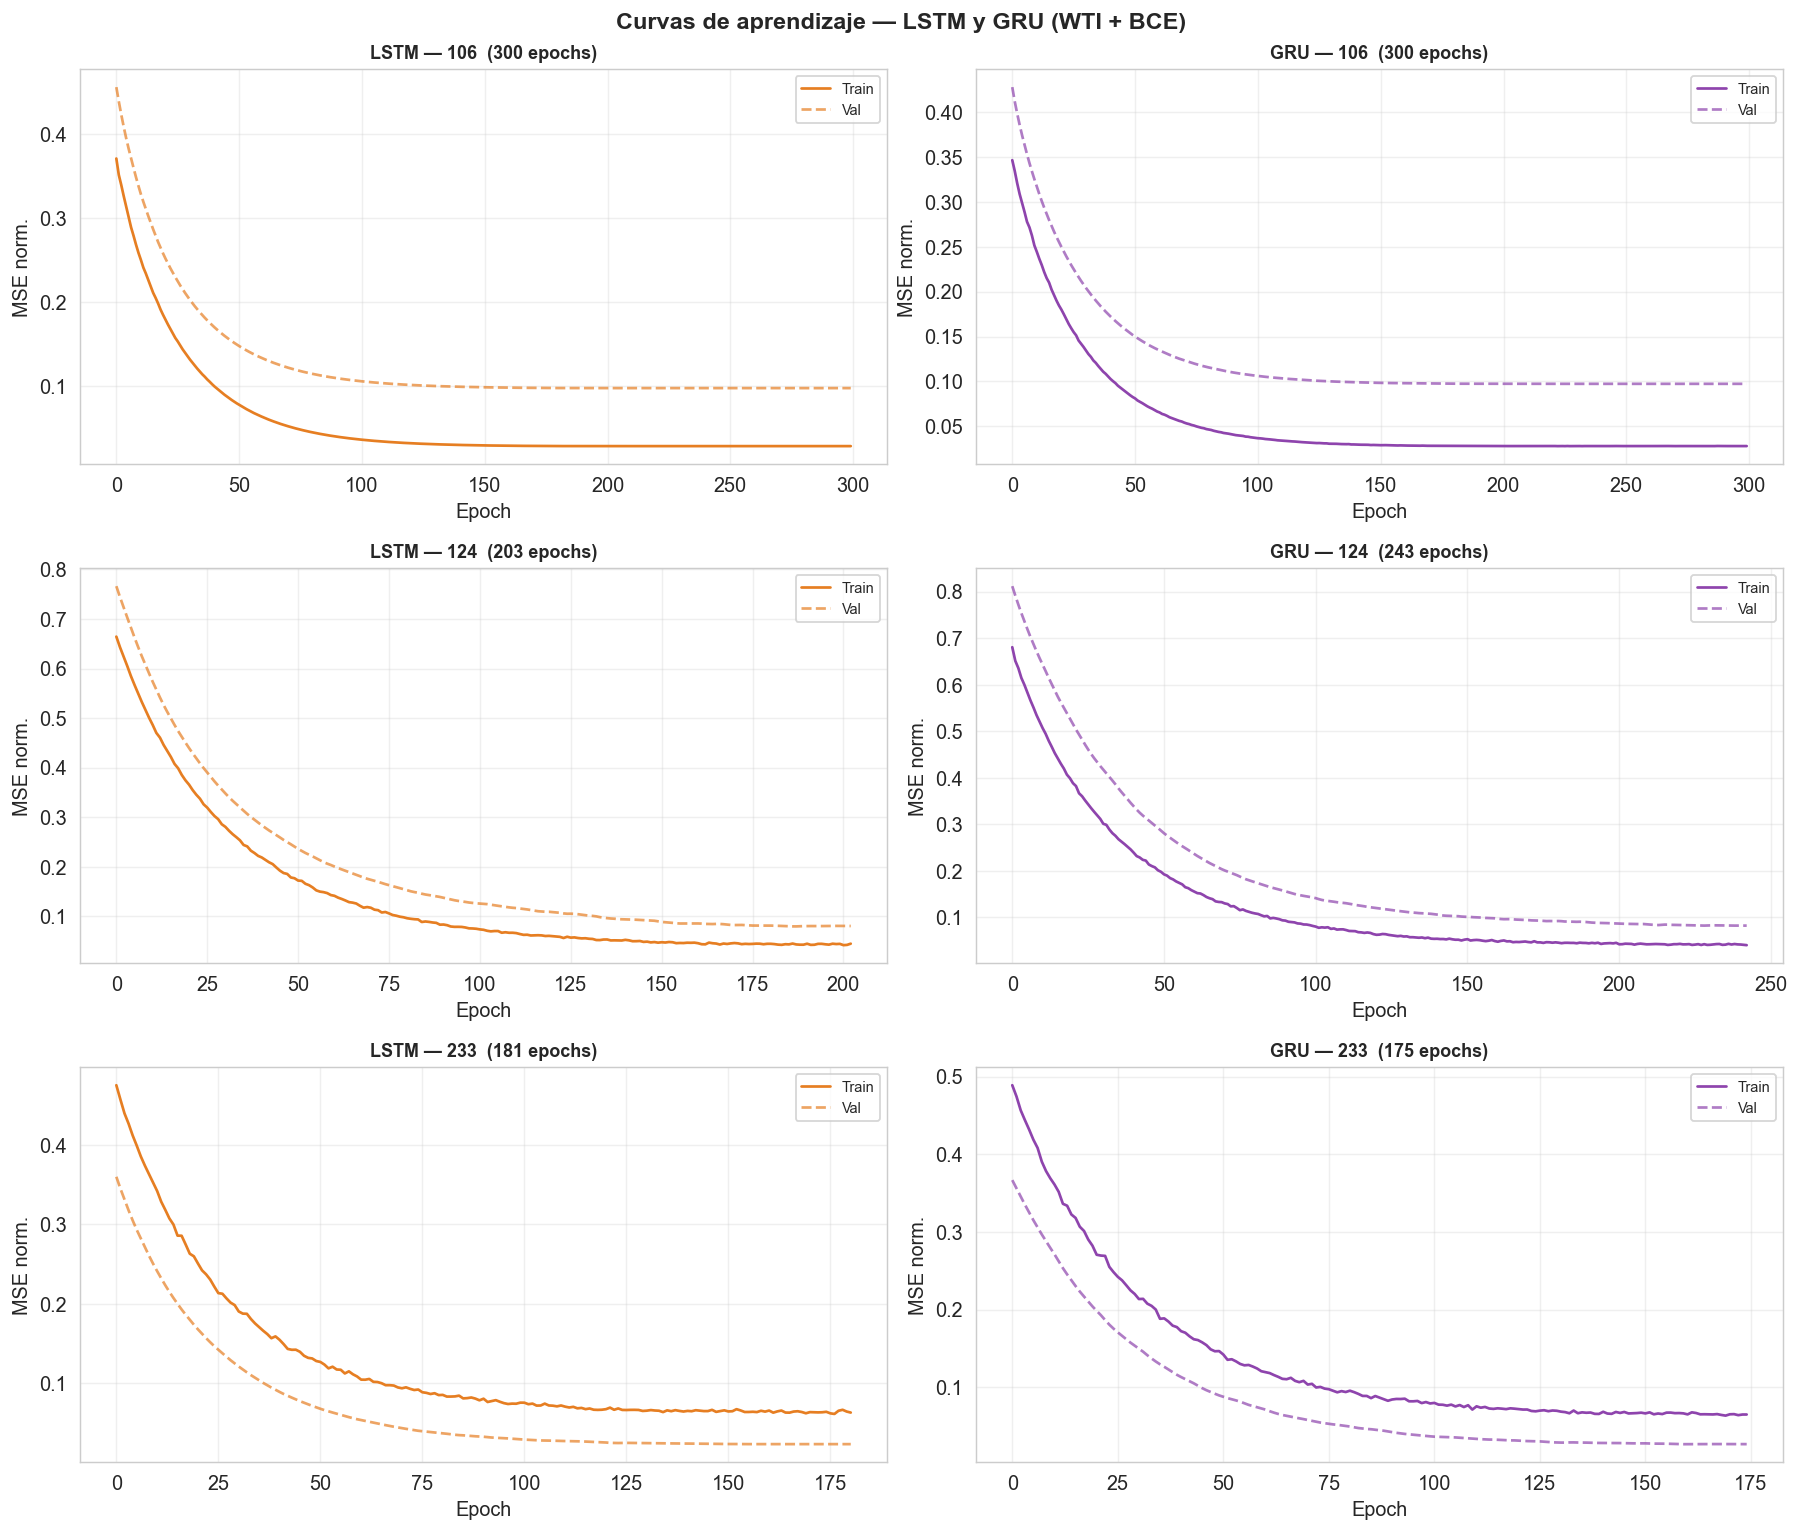

In [9]:
# ── 8. Curvas de aprendizaje ──────────────────────────────────────
COLORES = {'LSTM': '#e67e22', 'GRU': '#8e44ad'}

fig, axes = plt.subplots(len(FAMILIAS), 2, figsize=(14, 4*len(FAMILIAS)))
for row, familia in enumerate(FAMILIAS):
    for col, mtype in enumerate(['LSTM', 'GRU']):
        ax   = axes[row, col]
        hist = historiales[familia][mtype].history
        c    = COLORES[mtype]
        ax.plot(hist['loss'],     color=c, lw=1.5, label='Train')
        ax.plot(hist['val_loss'], color=c, lw=1.5, ls='--', alpha=0.7, label='Val')
        ax.set_title(f'{mtype} — {familia}  ({len(hist["loss"])} epochs)',
                     fontweight='bold', fontsize=10)
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE norm.')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje — LSTM y GRU (WTI + BCE)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figuras/05_curvas_aprendizaje.pdf', bbox_inches='tight')
plt.show()

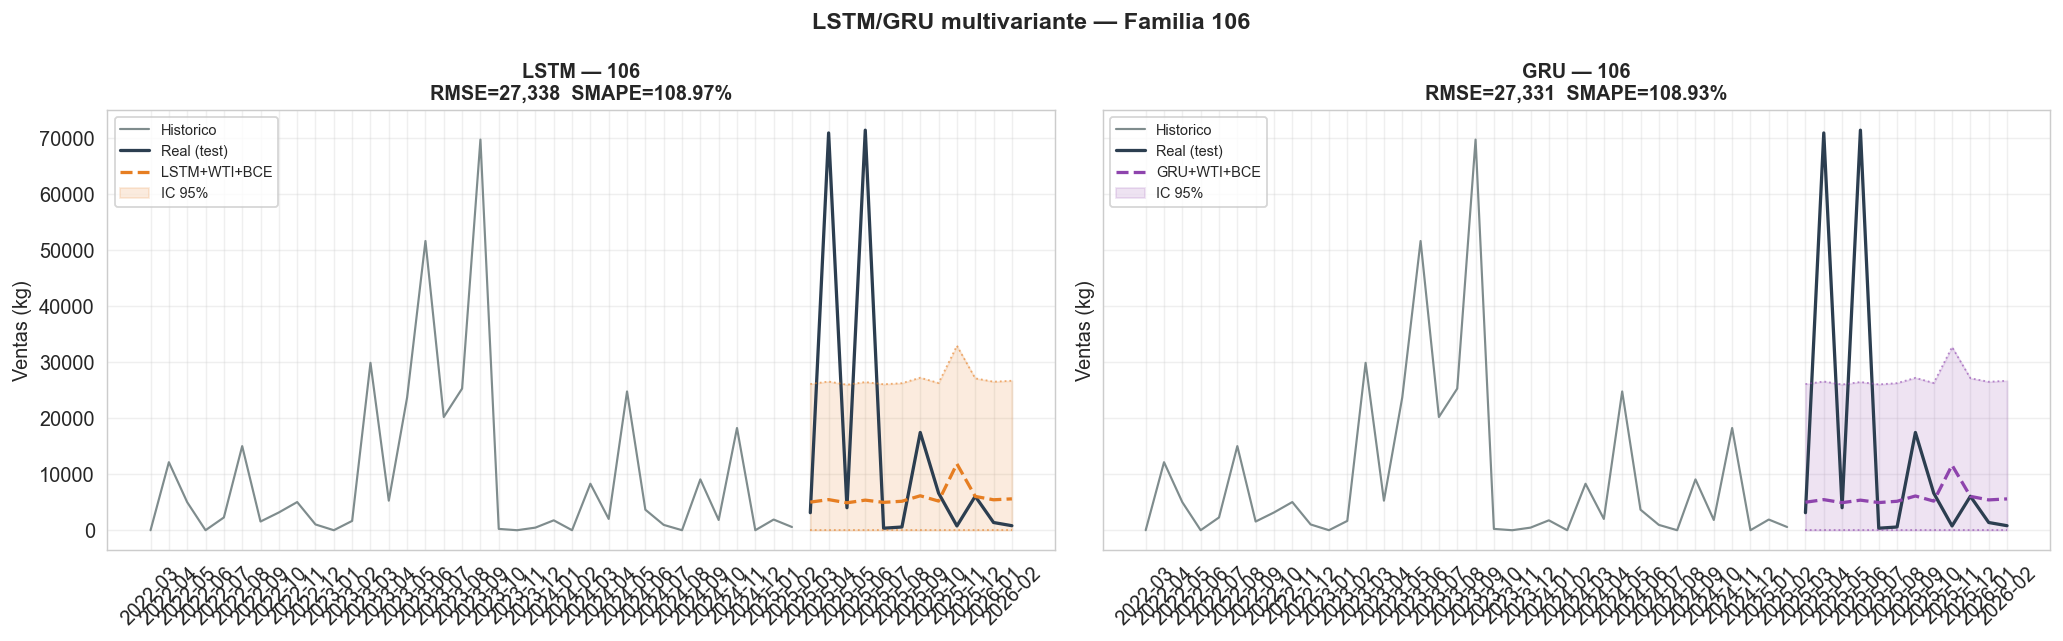

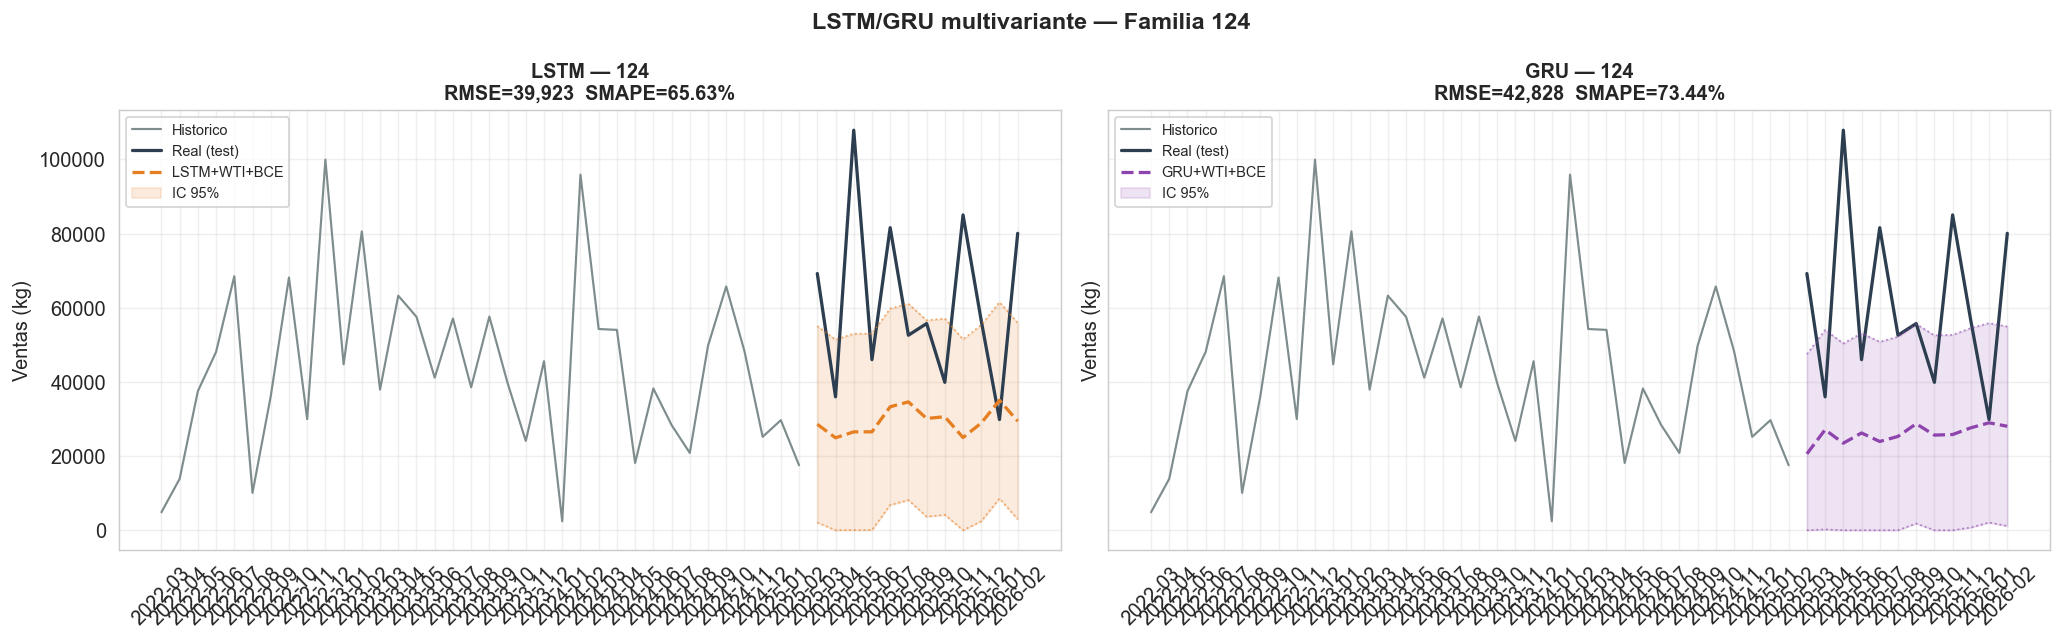

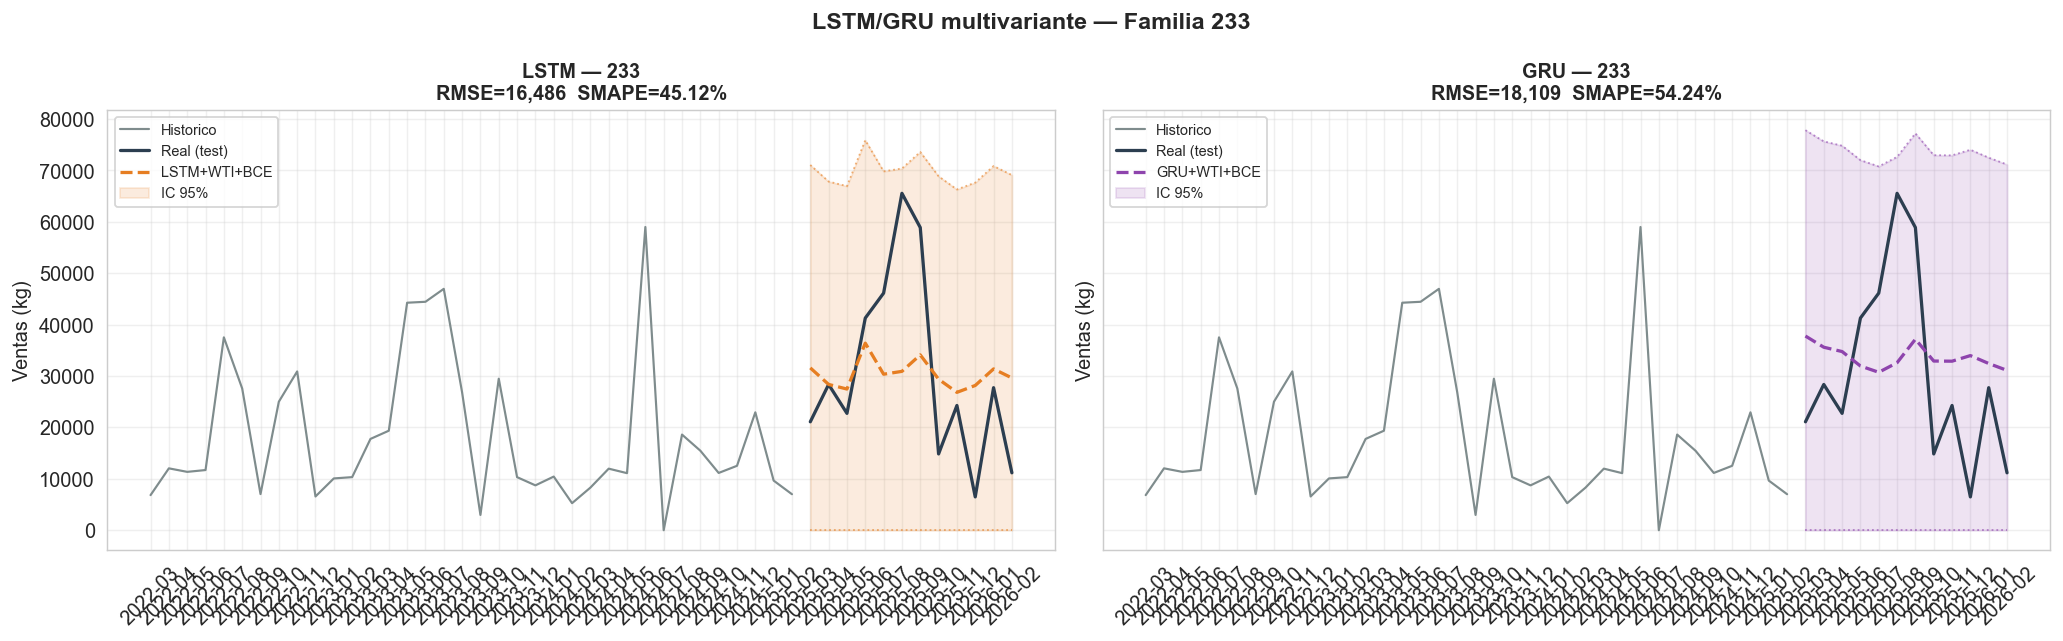

In [10]:
# ── 9. Predicciones ───────────────────────────────────────────────
for familia in FAMILIAS:
    serie    = datos_dl[familia]['serie_orig']
    n        = len(serie)
    test_idx = ventas_mensual.index[-H:].astype(str)
    ctx_idx  = ventas_mensual.index[n-H-36:].astype(str)
    ctx_tr   = serie[n-H-36:-H]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    for ax, mtype in zip(axes, ['LSTM', 'GRU']):
        pred  = predicciones_dl[familia][mtype]
        color = COLORES[mtype]
        ax.plot(list(ctx_idx[:36]), ctx_tr,
                color='#7f8c8d', lw=1.2, label='Historico')
        ax.plot(list(test_idx), pred['test'],
                color='#2c3e50', lw=1.8, label='Real (test)')
        ax.plot(list(test_idx), pred['fc_mean'],
                color=color, lw=1.8, ls='--', label=f'{mtype}+WTI+BCE')
        ax.plot(list(test_idx), pred['fc_lower'],
                color=color, lw=1.0, ls=':', alpha=0.6)
        ax.plot(list(test_idx), pred['fc_upper'],
                color=color, lw=1.0, ls=':', alpha=0.6)
        ax.fill_between(list(test_idx),
                        pred['fc_lower'], pred['fc_upper'],
                        alpha=0.15, color=color, label='IC 95%')
        
        res = resultados_lstm if mtype == 'LSTM' else resultados_gru
        m   = next(r for r in res if r['Familia'] == familia)
        ax.set_title(f'{mtype} — {familia}\n'
                     f'RMSE={m["RMSE"]:,.0f}  SMAPE={m["SMAPE_%"]}%',
                     fontweight='bold', fontsize=11)
        ax.set_ylabel('Ventas (kg)')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f'LSTM/GRU multivariante — Familia {familia}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../figuras/05_prediccion_DL_{familia}.pdf', bbox_inches='tight')
    plt.show()

SMAPE (%) — todos los modelos:
Modelo      GRU    LSTM
Familia                
106      105.94  136.82
124       67.11   82.92
233       55.03   55.10


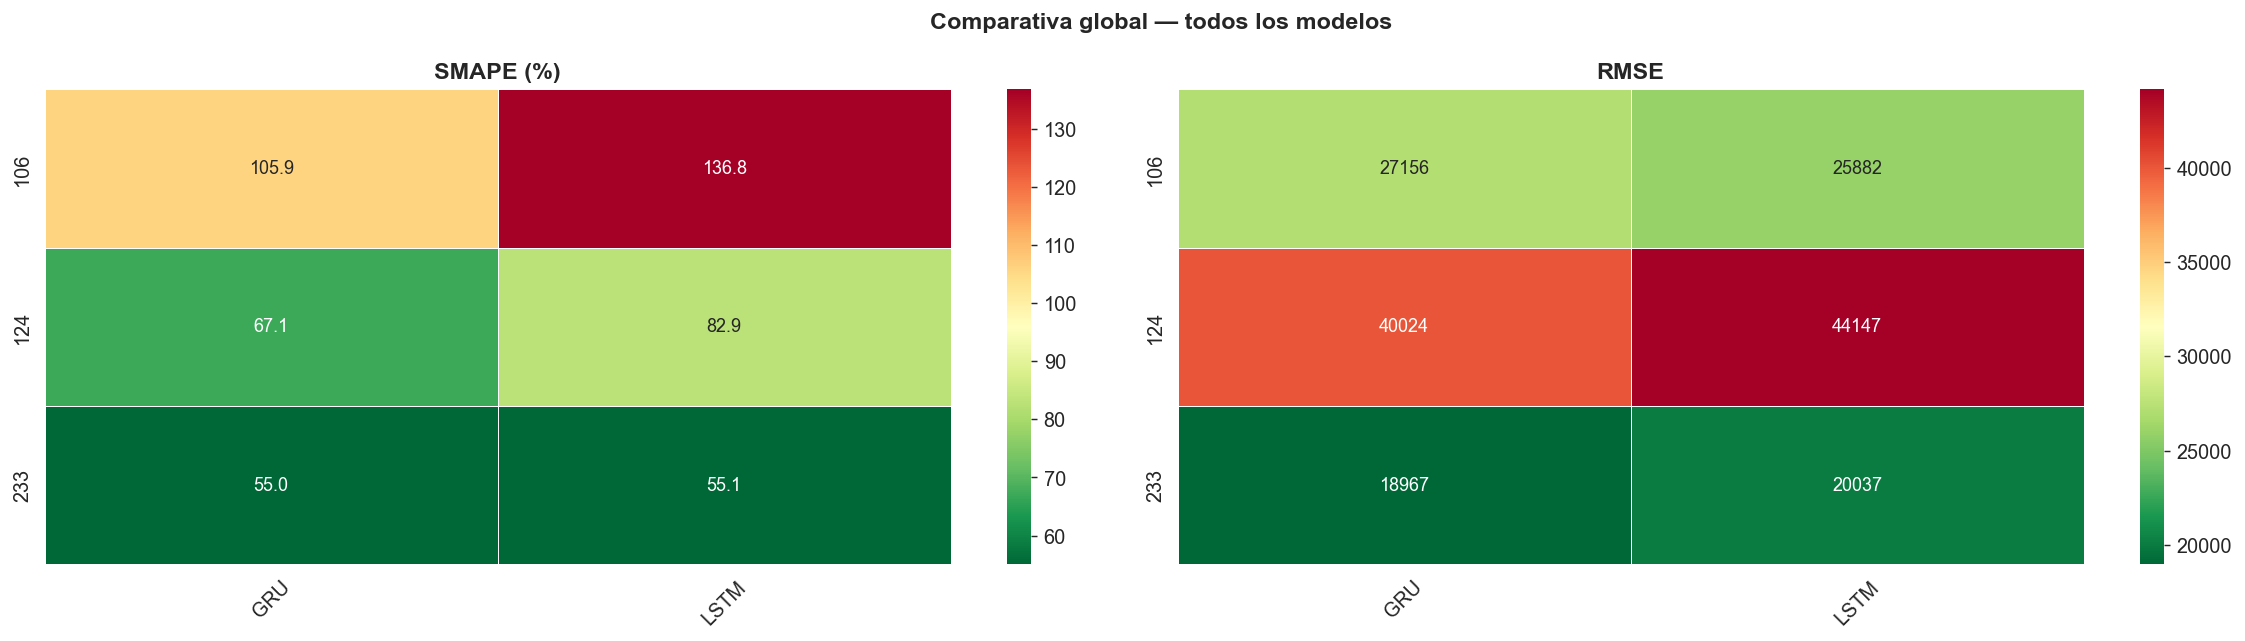

In [11]:

# ── 10. Comparativa global ────────────────────────────────────────
try:
    df_prev = pd.read_csv('../data/processed/05_metricas_global.csv')
except FileNotFoundError:
    df_prev = pd.DataFrame(columns=['Modelo','Familia','RMSE','MAE','MAPE_%','SMAPE_%'])

df_05    = pd.DataFrame(resultados_lstm + resultados_gru)
df_global = pd.concat(
    [df_prev[['Modelo','Familia','RMSE','MAE','MAPE_%','SMAPE_%']], df_05],
    ignore_index=True
)

tabla_smape = df_global.pivot_table(
    index='Familia', columns='Modelo', values='SMAPE_%').round(2)
tabla_rmse  = df_global.pivot_table(
    index='Familia', columns='Modelo', values='RMSE').round(0)

print('SMAPE (%) — todos los modelos:')
print(tabla_smape.to_string())

df_global.to_csv('../data/processed/05_metricas_global.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, (titulo, tabla) in zip(axes, [('SMAPE (%)', tabla_smape), ('RMSE', tabla_rmse)]):
    sns.heatmap(tabla, annot=True,
                fmt='.1f' if 'SMAPE' in titulo else '.0f',
                cmap='RdYlGn_r', ax=ax, linewidths=0.5, annot_kws={'size':10})
    ax.set_title(titulo, fontweight='bold', fontsize=13)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Comparativa global — todos los modelos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figuras/06_heatmap_global.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# ── 11. Resumen ───────────────────────────────────────────────────
print('=' * 65)
print('RESUMEN NOTEBOOK 05')
print('=' * 65)
for familia in FAMILIAS:
    ml = next(r for r in resultados_lstm if r['Familia'] == familia)
    mg = next(r for r in resultados_gru  if r['Familia'] == familia)
    mejor = 'LSTM' if ml['SMAPE_%'] < mg['SMAPE_%'] else 'GRU'
    print(f'\n[{familia}]')
    print(f'  LSTM  RMSE={ml["RMSE"]:>10,.2f}  SMAPE={ml["SMAPE_%"]:>6.2f}%')
    print(f'  GRU   RMSE={mg["RMSE"]:>10,.2f}  SMAPE={mg["SMAPE_%"]:>6.2f}%')
    print(f'  -> Mejor: {mejor}')
print('=' * 65)